# 12 — Walk-forward Cross-Validation del LSTM-Attention-Multi

**Objetivo**: validar de forma metodológicamente correcta las métricas reportadas para el modelo `LSTM_Attention_Multi` del notebook `11_v2_Colab_Multitarget.ipynb`.

**Por qué walk-forward**: en series temporales, una única división cronológica train/val/test puede dar resultados artificialmente buenos o malos según en qué año caiga el conjunto de test (estacionalidad, cambios estructurales, COVID, etc.). Walk-forward simula el escenario real de producción: entrenar con los datos disponibles hasta `t`, predecir `t+1`, avanzar `t` y repetir.

**Diseño del experimento**:
- 5 folds con ventana de entrenamiento creciente (*expanding window*)
- Cada estación se particiona por separado para evitar contaminación cruzada
- Mismo modelo, mismo scaler, mismas features que el notebook 11_v2
- Métricas: MAE, RMSE, R² por contaminante y por fold
- Resultado final: R² medio ± desviación estándar entre folds

**Tiempo estimado de ejecución**: ~35-40 minutos en Colab con GPU T4.

## 1. Imports y configuración

In [1]:
import os, json, time, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('TF version:', tf.__version__)
print('GPU disponible:', tf.config.list_physical_devices('GPU'))

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)

TF version: 2.20.0
GPU disponible: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
# Montaje de Google Drive (solo necesario en Colab)
try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
except ImportError:
    IN_COLAB = False
    print('Ejecutando en local')

Mounted at /content/drive


## 2. Constantes y funciones del pipeline

Estas funciones son **idénticas** a las del notebook `11_v2_Colab_Multitarget.ipynb` para garantizar comparabilidad directa de resultados.

In [3]:
TARGETS = ['pm25', 'no2', 'o3']
NON_FEATURE_COLS = ['station_name']
SEQ_LEN = 24  # 24 horas de contexto, igual que notebook 11_v2
N_FOLDS = 5

# Configuración de entrenamiento (idéntica a 11_v2)
EPOCHS = 60
BATCH = 128
PATIENCE_EARLY = 8
PATIENCE_LR = 4


def load_v2_dataset(path):
    df = pd.read_csv(path, parse_dates=['fecha'])
    df = df.sort_values(['station_name', 'fecha']).reset_index(drop=True)
    df = df.set_index('fecha')
    return df


def list_feature_columns(df):
    return [c for c in df.columns if c not in NON_FEATURE_COLS]


def build_sequences_multitarget(df, feature_cols, scaler, seq_len=SEQ_LEN,
                                targets=None, group_col='station_name',
                                max_gap_hours=1.0):
    """Construye secuencias (X, y) por estación respetando huecos temporales."""
    if targets is None:
        targets = TARGETS
    df = df.copy()
    df[feature_cols] = scaler.transform(df[feature_cols])
    target_idx = [feature_cols.index(t) for t in targets]
    xs, ys = [], []
    gap_threshold_ns = np.int64(int(max_gap_hours * 3_600 * 1_000_000_000))
    for _, group in df.groupby(group_col, sort=False):
        if len(group) <= seq_len:
            continue
        feat = group[feature_cols].to_numpy(dtype=np.float32)
        ts_ns = group.index.values.astype('datetime64[ns]').astype(np.int64)
        for i in range(len(group) - seq_len):
            j = i + seq_len
            diffs_ns = np.diff(ts_ns[i:j+1])
            if (diffs_ns > gap_threshold_ns).any():
                continue
            xs.append(feat[i:j])
            ys.append(feat[j, target_idx])
    if not xs:
        return (np.empty((0, seq_len, len(feature_cols)), dtype=np.float32),
                np.empty((0, len(targets)), dtype=np.float32))
    return np.stack(xs), np.stack(ys)


def inverse_transform_targets(y_scaled, scaler, feature_cols, targets=None):
    """Devuelve los targets en sus unidades originales (μg/m³)."""
    if targets is None:
        targets = TARGETS
    if y_scaled.ndim == 1:
        y_scaled = y_scaled.reshape(-1, len(targets))
    n = y_scaled.shape[0]
    dummy = np.zeros((n, len(feature_cols)), dtype=np.float32)
    target_idx = [feature_cols.index(t) for t in targets]
    for j, idx in enumerate(target_idx):
        dummy[:, idx] = y_scaled[:, j]
    inv = scaler.inverse_transform(dummy)
    return inv[:, target_idx]

## 3. Arquitectura del modelo

Definición idéntica a la del notebook `11_v2_Colab_Multitarget.ipynb`.

In [4]:
class BahdanauAttention(layers.Layer):
    def __init__(self, units, **kwargs):
        super().__init__(**kwargs)
        self.W = layers.Dense(units)
        self.U = layers.Dense(units)
        self.V = layers.Dense(1)

    def call(self, encoder_outputs):
        score = self.V(tf.nn.tanh(self.W(encoder_outputs) + self.U(encoder_outputs)))
        weights = tf.nn.softmax(score, axis=1)
        context = tf.reduce_sum(weights * encoder_outputs, axis=1)
        return context


def build_lstm_attention_multi(seq_len, n_features, n_targets, lr=1e-3, dropout=0.2):
    """LSTM-Attention-Multi: arquitectura ganadora del notebook 11_v2."""
    inp = layers.Input(shape=(seq_len, n_features))
    x = layers.LSTM(128, return_sequences=True)(inp)
    x = layers.Dropout(dropout)(x)
    x = layers.LSTM(64, return_sequences=True)(x)
    x = layers.Dropout(dropout)(x)
    x = BahdanauAttention(64)(x)
    x = layers.Dense(32, activation='relu')(x)
    out = layers.Dense(n_targets, name='output')(x)
    m = Model(inp, out, name='LSTM_Attention_Multi')
    m.compile(optimizer=keras.optimizers.Adam(lr), loss='mse', metrics=['mae'])
    return m

## 4. Walk-forward splitter

**Estrategia**: para cada estación, divido cronológicamente en 5 folds con *expanding window*. El conjunto de entrenamiento crece progresivamente y el de validación es siempre el siguiente bloque del 10% sin solapamiento.

```
Fold 1: train [0%-50%]   →  val [50%-60%]
Fold 2: train [0%-60%]   →  val [60%-70%]
Fold 3: train [0%-70%]   →  val [70%-80%]
Fold 4: train [0%-80%]   →  val [80%-90%]
Fold 5: train [0%-90%]   →  val [90%-100%]
```

Cada fold reserva además los últimos 10% del bloque de entrenamiento como conjunto de validación interno para `EarlyStopping`, replicando el comportamiento del notebook 11_v2.

In [5]:
def walk_forward_split_by_station(df, fold_idx, n_folds=N_FOLDS, internal_val_frac=0.1):
    """
    Devuelve (train_df, internal_val_df, test_df) para un fold concreto.

    Estrategia expanding window por estación:
    - fold k=0..n_folds-1
    - train: [0, train_end_k]
    - test:  [train_end_k, train_end_k + step]
    - internal_val: últimas `internal_val_frac` del bloque de train (para EarlyStopping)
    """
    train, internal_val, test = [], [], []
    for _, group in df.groupby('station_name', sort=False):
        n = len(group)
        # Bloque inicial 50%, crece 10% por fold, test siempre 10%
        train_end_frac = 0.5 + fold_idx * 0.1
        test_end_frac = train_end_frac + 0.1
        n_train_full = int(n * train_end_frac)
        n_test_end = int(n * test_end_frac)
        # División interna train / internal_val
        n_internal_val = int(n_train_full * internal_val_frac)
        n_train_eff = n_train_full - n_internal_val
        train.append(group.iloc[:n_train_eff])
        internal_val.append(group.iloc[n_train_eff:n_train_full])
        test.append(group.iloc[n_train_full:n_test_end])
    return (pd.concat(train), pd.concat(internal_val), pd.concat(test))

## 5. Evaluación por contaminante

In [6]:
def evaluate_multitarget(model, X, y, scaler, feature_cols, fold=None):
    """Devuelve un DataFrame con MAE, RMSE y R² por contaminante en unidades reales."""
    y_pred_scaled = model.predict(X, verbose=0)
    y_pred_real = inverse_transform_targets(y_pred_scaled, scaler, feature_cols)
    y_true_real = inverse_transform_targets(y, scaler, feature_cols)
    rows = []
    for j, t in enumerate(TARGETS):
        mae = mean_absolute_error(y_true_real[:, j], y_pred_real[:, j])
        rmse = np.sqrt(mean_squared_error(y_true_real[:, j], y_pred_real[:, j]))
        r2 = r2_score(y_true_real[:, j], y_pred_real[:, j])
        rows.append({'fold': fold, 'target': t, 'mae': mae, 'rmse': rmse, 'r2': r2})
    return pd.DataFrame(rows), y_pred_real, y_true_real

## 6. Carga del dataset

In [7]:
# Ajustar ruta según entorno
if IN_COLAB:
    DATA_PATH = '/content/drive/MyDrive/AirVLC/master_dataset_colab_v2.csv'
    OUTPUT_DIR = '/content/drive/MyDrive/AirVLC/walk_forward_results'
else:
    DATA_PATH = '../data/processed/master_dataset_colab_v2.csv'
    OUTPUT_DIR = '../data/processed/walk_forward_results'

os.makedirs(OUTPUT_DIR, exist_ok=True)

df = load_v2_dataset(DATA_PATH)
feature_cols = list_feature_columns(df)

print(f'Dataset shape: {df.shape}')
print(f'Estaciones: {df["station_name"].nunique()}')
print(f'Rango temporal: {df.index.min()} → {df.index.max()}')
print(f'Features ({len(feature_cols)}): {feature_cols}')

Dataset shape: (194321, 45)
Estaciones: 7
Rango temporal: 2016-01-02 00:00:00 → 2026-05-12 05:00:00
Features (44): ['pm25', 'no2', 'o3', 'temperatura', 'velocidad_viento', 'precipitacion', 'humedad_relativa', 'hora_del_dia', 'dia_de_la_semana', 'mes', 'is_weekend', 'is_fallas', 'pm25_lag1', 'pm25_lag3', 'pm25_lag6', 'pm25_lag24', 'no2_lag1', 'no2_lag3', 'no2_lag6', 'no2_lag24', 'o3_lag1', 'o3_lag3', 'o3_lag6', 'o3_lag24', 'pm25_rolling_6h', 'pm25_rolling_12h', 'pm25_rolling_24h', 'no2_rolling_6h', 'no2_rolling_12h', 'no2_rolling_24h', 'o3_rolling_6h', 'o3_rolling_12h', 'o3_rolling_24h', 'hora_sin', 'hora_cos', 'mes_sin', 'mes_cos', 'station_Francia', 'station_Molí del Sol', 'station_Pista de Silla', 'station_Puerto Moll Trans. Ponent', 'station_Puerto Valencia', 'station_Puerto llit antic Túria', 'station_Universidad Politécnica']


## 7. Ejecución del Walk-forward Cross-Validation

Bucle principal: para cada uno de los 5 folds, ajusto el scaler con los datos de entrenamiento del fold (importante: el scaler **no debe ver el futuro**), construyo las secuencias, entreno el modelo desde cero y evalúo en el bloque de test del fold.

In [8]:
all_results = []
fold_histories = []
fold_predictions = {}

t_global = time.time()

for fold in range(N_FOLDS):
    print('\n' + '=' * 80)
    print(f'FOLD {fold + 1} / {N_FOLDS}')
    print('=' * 80)

    # 1. Split temporal por estación
    train_df, internal_val_df, test_df = walk_forward_split_by_station(df, fold)
    print(f'  Train rows: {len(train_df):,}  Internal val: {len(internal_val_df):,}  Test: {len(test_df):,}')
    print(f'  Train range: {train_df.index.min()} → {train_df.index.max()}')
    print(f'  Test range:  {test_df.index.min()} → {test_df.index.max()}')

    # 2. Ajustar scaler SOLO con train (no contaminar con el futuro)
    scaler = MinMaxScaler()
    scaler.fit(train_df[feature_cols])

    # 3. Construir secuencias
    X_train, y_train = build_sequences_multitarget(train_df, feature_cols, scaler)
    X_val, y_val = build_sequences_multitarget(internal_val_df, feature_cols, scaler)
    X_test, y_test = build_sequences_multitarget(test_df, feature_cols, scaler)

    if X_train.shape[0] == 0 or X_test.shape[0] == 0:
        print(f'  ⚠️ Fold {fold + 1} tiene secuencias insuficientes, saltando.')
        continue

    print(f'  Secuencias → train: {X_train.shape[0]:,}  val: {X_val.shape[0]:,}  test: {X_test.shape[0]:,}')

    # 4. Construir y entrenar el modelo desde cero
    tf.keras.backend.clear_session()
    tf.random.set_seed(SEED + fold)  # ligera variación por fold para diversidad
    np.random.seed(SEED + fold)

    model = build_lstm_attention_multi(SEQ_LEN, len(feature_cols), len(TARGETS))

    callbacks = [
        EarlyStopping(monitor='val_loss', patience=PATIENCE_EARLY, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=PATIENCE_LR, min_lr=1e-6),
    ]

    t0 = time.time()
    hist = model.fit(X_train, y_train,
                     validation_data=(X_val, y_val),
                     epochs=EPOCHS, batch_size=BATCH,
                     callbacks=callbacks, verbose=2)
    train_time = time.time() - t0
    best_epoch = int(np.argmin(hist.history['val_loss'])) + 1
    print(f'  Fold {fold + 1}: {train_time:.1f}s, best epoch {best_epoch}/{EPOCHS}')

    # 5. Evaluación en test
    fold_results, y_pred_real, y_true_real = evaluate_multitarget(
        model, X_test, y_test, scaler, feature_cols, fold=fold + 1)
    fold_results['train_time_sec'] = round(train_time, 1)
    fold_results['best_epoch'] = best_epoch
    fold_results['n_train'] = X_train.shape[0]
    fold_results['n_test'] = X_test.shape[0]

    print(f'\n  Resultados fold {fold + 1}:')
    print(fold_results[['target', 'mae', 'rmse', 'r2']].to_string(
        index=False, float_format=lambda x: f'{x:.4f}'))

    all_results.append(fold_results)
    fold_histories.append(hist.history)
    fold_predictions[fold + 1] = {'y_true': y_true_real, 'y_pred': y_pred_real}

total_time = time.time() - t_global
print('\n' + '=' * 80)
print(f'Walk-forward CV completado en {total_time / 60:.1f} minutos')
print('=' * 80)


FOLD 1 / 5
  Train rows: 87,446  Internal val: 9,713  Test: 19,431
  Train range: 2016-01-02 00:00:00 → 2021-09-08 00:00:00
  Test range:  2018-12-26 07:00:00 → 2021-10-10 15:00:00
  Secuencias → train: 85,530  val: 9,353  test: 19,023
Epoch 1/60
669/669 - 14s - 21ms/step - loss: 0.0188 - mae: 0.1017 - val_loss: 0.0109 - val_mae: 0.0768 - learning_rate: 0.0010
Epoch 2/60
669/669 - 8s - 12ms/step - loss: 0.0087 - mae: 0.0667 - val_loss: 0.0056 - val_mae: 0.0522 - learning_rate: 0.0010
Epoch 3/60
669/669 - 6s - 10ms/step - loss: 0.0067 - mae: 0.0571 - val_loss: 0.0048 - val_mae: 0.0469 - learning_rate: 0.0010
Epoch 4/60
669/669 - 8s - 13ms/step - loss: 0.0061 - mae: 0.0538 - val_loss: 0.0045 - val_mae: 0.0451 - learning_rate: 0.0010
Epoch 5/60
669/669 - 8s - 12ms/step - loss: 0.0058 - mae: 0.0521 - val_loss: 0.0044 - val_mae: 0.0436 - learning_rate: 0.0010
Epoch 6/60
669/669 - 8s - 13ms/step - loss: 0.0056 - mae: 0.0509 - val_loss: 0.0045 - val_mae: 0.0448 - learning_rate: 0.0010
Epoch 

## 8. Resultados agregados

Métricas finales: media y desviación estándar entre folds, por contaminante.

In [9]:
results_df = pd.concat(all_results, ignore_index=True)

# Tabla detallada fold × target
print('Resultados por fold y contaminante:')
print('=' * 80)
pivot = results_df.pivot_table(index='fold', columns='target',
                                values='r2', aggfunc='first')
print(pivot.to_string(float_format=lambda x: f'{x:.4f}'))

# Agregación
agg = (results_df.groupby('target')
       .agg(r2_mean=('r2', 'mean'),
            r2_std=('r2', 'std'),
            mae_mean=('mae', 'mean'),
            mae_std=('mae', 'std'),
            rmse_mean=('rmse', 'mean'),
            rmse_std=('rmse', 'std'))
       .round(4))

print('\n\nMétricas agregadas (media ± desviación estándar entre folds):')
print('=' * 80)
print(agg.to_string())

# Guardar resultados
results_df.to_csv(os.path.join(OUTPUT_DIR, 'walk_forward_per_fold.csv'), index=False)
agg.to_csv(os.path.join(OUTPUT_DIR, 'walk_forward_aggregated.csv'))
print(f'\nResultados guardados en {OUTPUT_DIR}')

Resultados por fold y contaminante:
target    no2     o3   pm25
fold                       
1      0.8294 0.8902 0.8680
2      0.8359 0.8954 0.8839
3      0.8260 0.8962 0.8569
4      0.8361 0.8928 0.8891
5      0.8405 0.8866 0.8575


Métricas agregadas (media ± desviación estándar entre folds):
        r2_mean  r2_std  mae_mean  mae_std  rmse_mean  rmse_std
target                                                         
no2      0.8336  0.0058    4.3965   0.5977     6.6643    0.8173
o3       0.8922  0.0039    6.1825   0.2447     8.8826    0.3384
pm25     0.8711  0.0149    1.8168   0.2590     3.2559    0.3963

Resultados guardados en /content/drive/MyDrive/AirVLC/walk_forward_results


## 9. Comparativa: Walk-forward vs División única (notebook 11_v2)

Tabla que se usará directamente en la memoria y en el README.

In [10]:
# Resultados originales del notebook 11_v2 (división única 80/10/10)
results_11v2 = pd.DataFrame({
    'target': ['pm25', 'no2', 'o3'],
    'r2_11v2': [0.8571, 0.8397, 0.8861],
    'mae_11v2': [1.5681, 3.8648, 6.2557],
    'rmse_11v2': [2.8279, 5.9141, 8.8754],
})

comparison = agg.reset_index().merge(results_11v2, on='target')
comparison = comparison[['target',
                          'r2_11v2', 'r2_mean', 'r2_std',
                          'mae_11v2', 'mae_mean', 'mae_std',
                          'rmse_11v2', 'rmse_mean', 'rmse_std']]
comparison.columns = ['target',
                       'R² (split único)', 'R² (walk-forward)', 'R² std',
                       'MAE (split único)', 'MAE (walk-forward)', 'MAE std',
                       'RMSE (split único)', 'RMSE (walk-forward)', 'RMSE std']

print('Comparativa de metodologías:')
print('=' * 100)
print(comparison.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

comparison.to_csv(os.path.join(OUTPUT_DIR, 'walk_forward_vs_single_split.csv'), index=False)

Comparativa de metodologías:
target  R² (split único)  R² (walk-forward)  R² std  MAE (split único)  MAE (walk-forward)  MAE std  RMSE (split único)  RMSE (walk-forward)  RMSE std
   no2            0.8397             0.8336  0.0058             3.8648              4.3965   0.5977              5.9141               6.6643    0.8173
    o3            0.8861             0.8922  0.0039             6.2557              6.1825   0.2447              8.8754               8.8826    0.3384
  pm25            0.8571             0.8711  0.0149             1.5681              1.8168   0.2590              2.8279               3.2559    0.3963


## 10. Visualizaciones

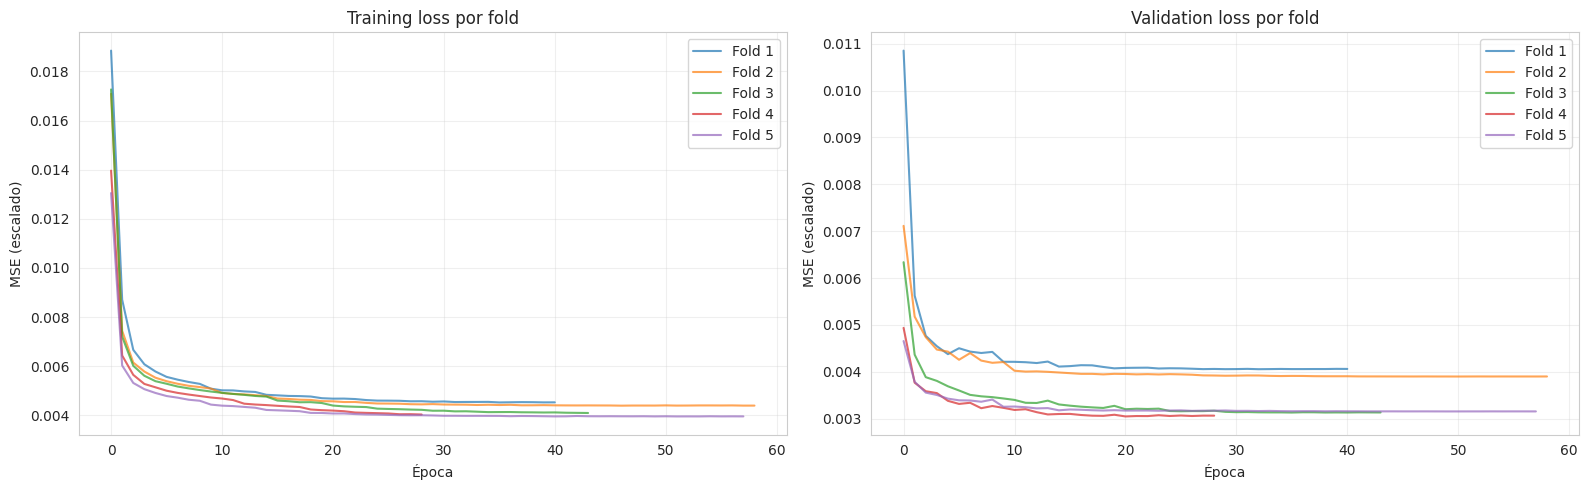

In [11]:
# Curvas de loss por fold
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for fold_idx, hist in enumerate(fold_histories):
    axes[0].plot(hist['loss'], label=f'Fold {fold_idx + 1}', alpha=0.7)
    axes[1].plot(hist['val_loss'], label=f'Fold {fold_idx + 1}', alpha=0.7)

axes[0].set_title('Training loss por fold')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('MSE (escalado)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].set_title('Validation loss por fold')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('MSE (escalado)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'walk_forward_loss_curves.png'), dpi=120, bbox_inches='tight')
plt.show()

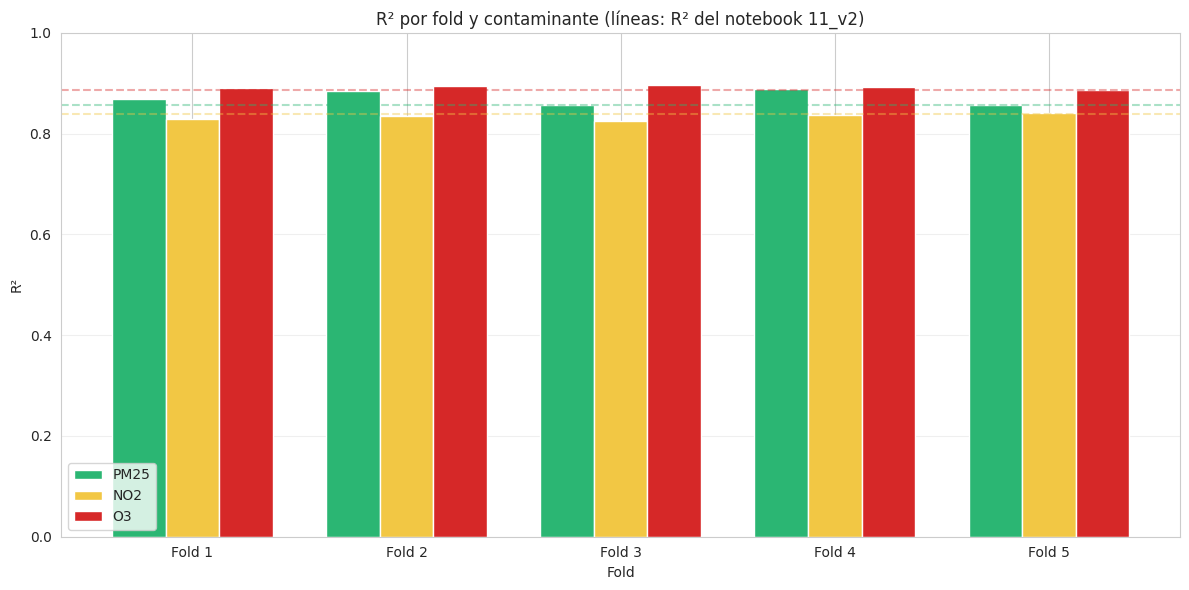

In [12]:
# R² por fold y contaminante (barras agrupadas)
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(N_FOLDS)
width = 0.25
colors = {'pm25': '#2BB673', 'no2': '#F2C744', 'o3': '#D62828'}

for i, target in enumerate(TARGETS):
    target_r2 = results_df[results_df['target'] == target].sort_values('fold')['r2'].values
    ax.bar(x + i * width, target_r2, width, label=target.upper(), color=colors[target])
    # Línea de referencia: R² del notebook 11_v2
    ref_r2 = results_11v2[results_11v2['target'] == target]['r2_11v2'].values[0]
    ax.axhline(y=ref_r2, color=colors[target], linestyle='--', alpha=0.4)

ax.set_xlabel('Fold')
ax.set_ylabel('R²')
ax.set_title('R² por fold y contaminante (líneas: R² del notebook 11_v2)')
ax.set_xticks(x + width)
ax.set_xticklabels([f'Fold {i + 1}' for i in range(N_FOLDS)])
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'walk_forward_r2_per_fold.png'), dpi=120, bbox_inches='tight')
plt.show()

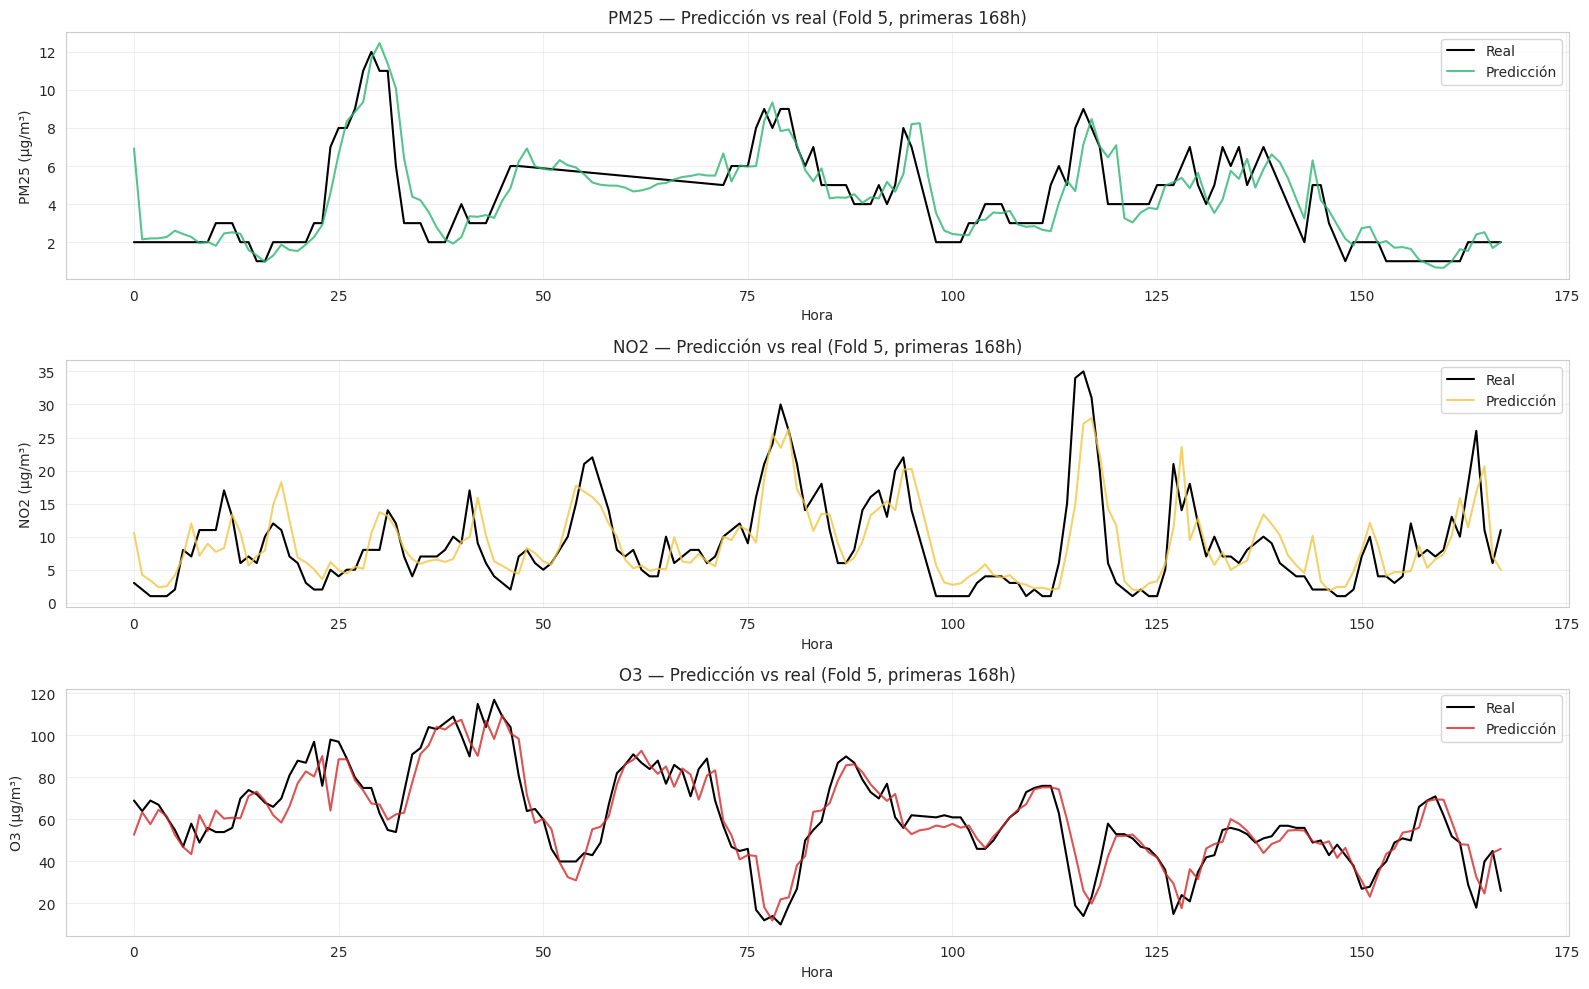

In [13]:
# Predicción vs Real para el último fold (más cercano al escenario de producción)
last_fold = N_FOLDS
y_true = fold_predictions[last_fold]['y_true']
y_pred = fold_predictions[last_fold]['y_pred']

# Limito a una ventana de 7 días (168h) para legibilidad
WINDOW_HOURS = 168
sample = slice(0, min(WINDOW_HOURS, len(y_true)))

fig, axes = plt.subplots(3, 1, figsize=(16, 10))

for i, (target, ax) in enumerate(zip(TARGETS, axes)):
    ax.plot(y_true[sample, i], label='Real', color='black', linewidth=1.5)
    ax.plot(y_pred[sample, i], label='Predicción', color=colors[target], linewidth=1.5, alpha=0.8)
    ax.set_title(f'{target.upper()} — Predicción vs real (Fold {last_fold}, primeras {WINDOW_HOURS}h)')
    ax.set_xlabel('Hora')
    ax.set_ylabel(f'{target.upper()} (μg/m³)')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'walk_forward_pred_vs_real.png'), dpi=120, bbox_inches='tight')
plt.show()

## 11. Tabla en Markdown para la memoria y el README

In [14]:
# Genera bloque Markdown listo para pegar
md_lines = [
    '## Resultados Walk-Forward Cross-Validation (5 folds)',
    '',
    'Modelo: **LSTM-Attention-Multi** (mismo del notebook `11_v2_Colab_Multitarget.ipynb`)',
    '',
    '| Contaminante | R² medio | R² std | MAE (μg/m³) | RMSE (μg/m³) | R² split único |',
    '|---|---|---|---|---|---|',
]

for target in TARGETS:
    row = agg.loc[target]
    ref_r2 = results_11v2[results_11v2['target'] == target]['r2_11v2'].values[0]
    md_lines.append(
        f'| {target.upper()} | {row["r2_mean"]:.4f} | ±{row["r2_std"]:.4f} | '
        f'{row["mae_mean"]:.3f} | {row["rmse_mean"]:.3f} | {ref_r2:.4f} |'
    )

md_lines.append('')
md_lines.append(f'**R² medio entre los 3 contaminantes**: {agg["r2_mean"].mean():.4f} ± {agg["r2_std"].mean():.4f}')
md_lines.append('')
md_lines.append('La validación walk-forward confirma la robustez del modelo frente a la división temporal única.')

md_block = '\n'.join(md_lines)
print(md_block)

# Guardar el bloque
with open(os.path.join(OUTPUT_DIR, 'results_for_readme.md'), 'w') as f:
    f.write(md_block)

print(f'\n\nBloque Markdown guardado en {OUTPUT_DIR}/results_for_readme.md')

## Resultados Walk-Forward Cross-Validation (5 folds)

Modelo: **LSTM-Attention-Multi** (mismo del notebook `11_v2_Colab_Multitarget.ipynb`)

| Contaminante | R² medio | R² std | MAE (μg/m³) | RMSE (μg/m³) | R² split único |
|---|---|---|---|---|---|
| PM25 | 0.8711 | ±0.0149 | 1.817 | 3.256 | 0.8571 |
| NO2 | 0.8336 | ±0.0058 | 4.396 | 6.664 | 0.8397 |
| O3 | 0.8922 | ±0.0039 | 6.183 | 8.883 | 0.8861 |

**R² medio entre los 3 contaminantes**: 0.8656 ± 0.0082

La validación walk-forward confirma la robustez del modelo frente a la división temporal única.


Bloque Markdown guardado en /content/drive/MyDrive/AirVLC/walk_forward_results/results_for_readme.md


## 12. Resumen ejecutivo

Última celda: imprime el resumen final para que copies y pegues directamente en la presentación oral.

In [15]:
print('=' * 80)
print('RESUMEN EJECUTIVO — WALK-FORWARD CV LSTM-ATTENTION-MULTI')
print('=' * 80)
print(f'Folds ejecutados: {N_FOLDS}')
print(f'Estaciones: {df["station_name"].nunique()}')
print(f'Rango temporal del dataset: {df.index.min().date()} → {df.index.max().date()}')
print(f'Tiempo total de ejecución: {total_time / 60:.1f} minutos')
print()
print('Métricas finales (media ± std entre folds):')
for target in TARGETS:
    row = agg.loc[target]
    print(f'  {target.upper():6s} → R² = {row["r2_mean"]:.4f} ± {row["r2_std"]:.4f}  |  '
          f'MAE = {row["mae_mean"]:.3f}  |  RMSE = {row["rmse_mean"]:.3f}')
print()
print(f'R² global promedio: {agg["r2_mean"].mean():.4f}')
print()
print('Mensaje clave para la presentación:')
print(f'  "El modelo mantiene un R² medio de {agg["r2_mean"].mean():.3f } con validación walk-forward')
print(f'   de 5 folds, demostrando estabilidad temporal y descartando que las métricas')
print(f'   originales fueran artefacto de una división favorable de los datos."')

RESUMEN EJECUTIVO — WALK-FORWARD CV LSTM-ATTENTION-MULTI
Folds ejecutados: 5
Estaciones: 7
Rango temporal del dataset: 2016-01-02 → 2026-05-12
Tiempo total de ejecución: 39.9 minutos

Métricas finales (media ± std entre folds):
  PM25   → R² = 0.8711 ± 0.0149  |  MAE = 1.817  |  RMSE = 3.256
  NO2    → R² = 0.8336 ± 0.0058  |  MAE = 4.396  |  RMSE = 6.664
  O3     → R² = 0.8922 ± 0.0039  |  MAE = 6.183  |  RMSE = 8.883

R² global promedio: 0.8656

Mensaje clave para la presentación:


ValueError: Invalid format specifier '.3f ' for object of type 'float'